In [2]:
!pip install tensorflow

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [5]:
import os

# The 'path' variable from the previous cell is a directory:
# '/kaggle/input/brain-tumor-mri-dataset'

print(f"Contents of the directory '{path}':")
for item in os.listdir(path):
    print(item)

# The original line 'df = pd.read_csv(path)' caused an IsADirectoryError.
# This is because the dataset appears to be an image dataset, not tabular data.
# You will need to use appropriate functions for loading image data (e.g., from TensorFlow/Keras).

Contents of the directory '/kaggle/input/brain-tumor-mri-dataset':
Training
Testing


In [6]:
import os

train_dir = os.path.join(path, 'Training')
test_dir = os.path.join(path, 'Testing')

print(f"Training directory: {train_dir}")
print(f"Testing directory: {test_dir}")

Training directory: /kaggle/input/brain-tumor-mri-dataset/Training
Testing directory: /kaggle/input/brain-tumor-mri-dataset/Testing


In [7]:
from tensorflow.keras.utils import image_dataset_from_directory

image_size = (256, 256)
batch_size = 32

train_ds = image_dataset_from_directory(
    train_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical'
)

print("Training dataset loaded successfully.")

Found 5600 files belonging to 4 classes.
Training dataset loaded successfully.


In [8]:
test_ds = image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical'
)

print("Testing dataset loaded successfully.")

Found 1600 files belonging to 4 classes.
Testing dataset loaded successfully.


In [9]:
for images, labels in train_ds.take(1):
    print("Shape of images batch:", images.shape)
    print("Shape of labels batch:", labels.shape)
    print("Class names:", train_ds.class_names)


Shape of images batch: (32, 256, 256, 3)
Shape of labels batch: (32, 4)
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [10]:
#CNN
model = Sequential()
model.add(layers.Conv2D(32, kernel_size=3, activation='relu', input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D(pool_size=2))
model.add(layers.Conv2D(64, kernel_size=3, activation='relu'))
model.add(layers.MaxPooling2D(pool_size=2))
model.add(layers.Conv2D(128, kernel_size=3, activation='relu'))
model.add(layers.MaxPooling2D(pool_size=2))
model.add(layers.Conv2D(256, kernel_size=3, activation='relu'))
model.add(layers.MaxPooling2D(pool_size=2))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(4, activation='softmax'))

model

<Sequential name=sequential, built=True>

In [11]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [12]:
history = model.fit(train_ds, epochs = 50)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 108ms/step - accuracy: 0.5994 - loss: 47.2013
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.8455 - loss: 0.4403
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.9088 - loss: 0.2607
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.9386 - loss: 0.1727
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.9574 - loss: 0.1249
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.9730 - loss: 0.0872
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.9879 - loss: 0.0323
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.9817 - loss: 0.0595
Epoch 9/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.9861 - loss: 0.0390
Epoch 10/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.9842 - loss: 0.0474
Epoch 11/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.9855 - loss: 0.0461
Epoch 12/50
175/175 ━━━━━━━━

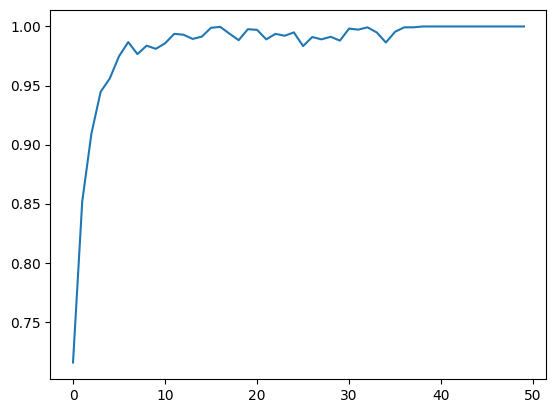

In [13]:
plt.plot(history.history['accuracy'])


In [14]:
prediction = model.predict(test_ds)
prediction

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step


array([[8.7875862e-37, 7.7161133e-25, 1.0000000e+00, 5.8218967e-32],
       [6.7884194e-08, 9.9998093e-01, 1.9002242e-05, 1.5794493e-09],
       [5.7547154e-14, 7.1177210e-11, 1.0000000e+00, 1.2716742e-10],
       ...,
       [1.7443919e-05, 9.9998248e-01, 1.2331569e-07, 2.7401564e-10],
       [6.2050684e-31, 1.0462979e-14, 4.9830746e-18, 1.0000000e+00],
       [2.0550862e-15, 4.6376020e-10, 1.0000000e+00, 1.9282467e-10]],
      dtype=float32)

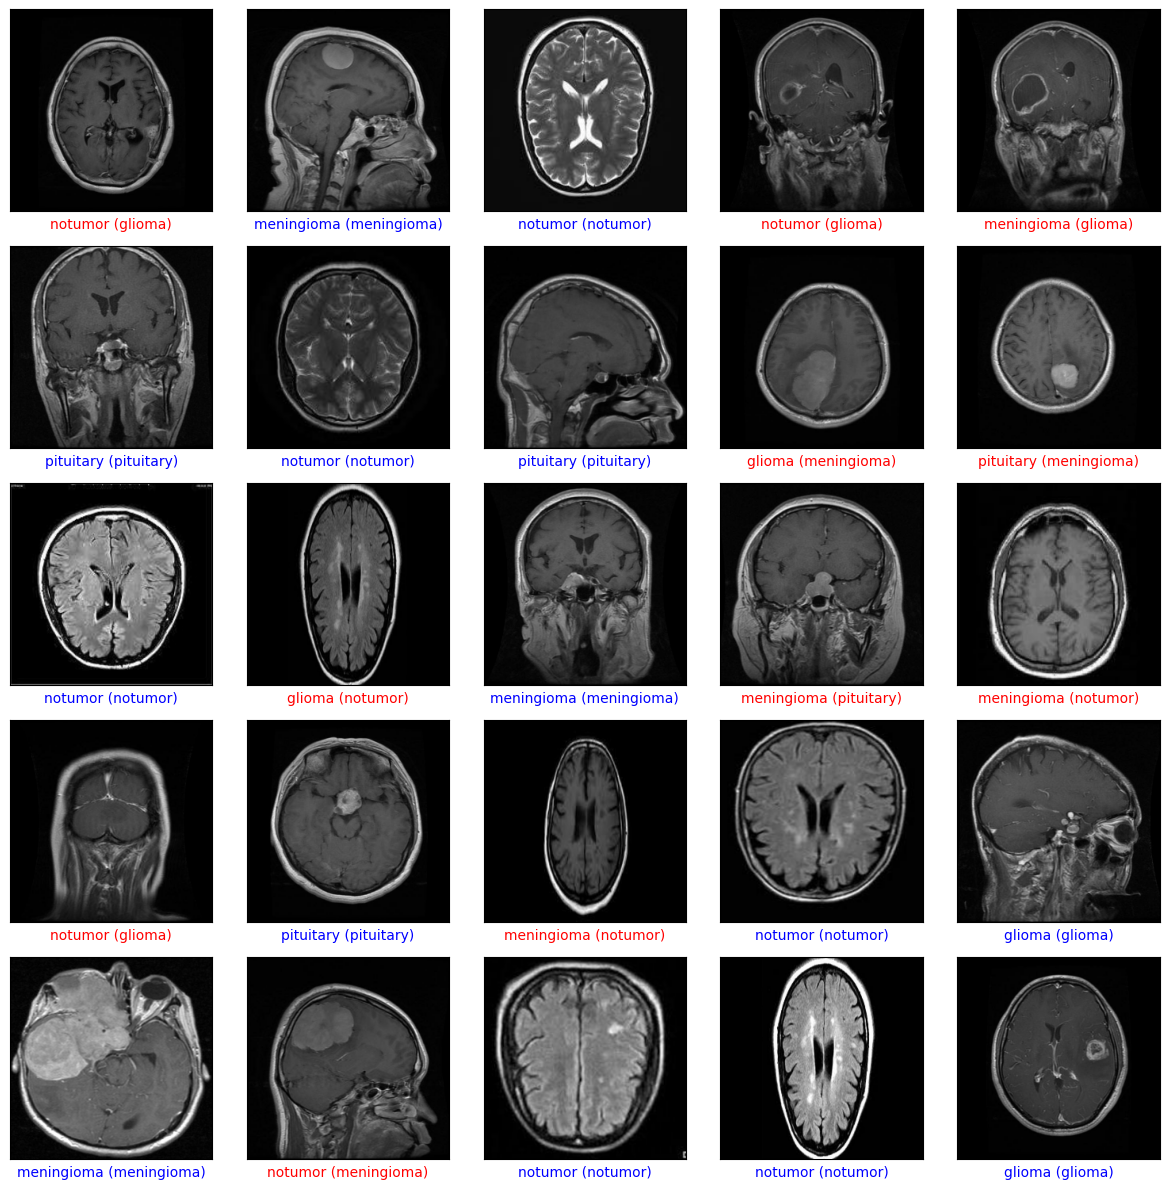

In [21]:
# Define function to plot images with predictions
def plot_image_predictions(images, true_labels_indices, prediction, class_names):
    plt.figure(figsize=(12, 12))
    for i in range(min(25, len(images))): # Plot up to 25 images or fewer if less available
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        # Ensure images are in the correct format for display (e.g., uint8 for 0-255 scale)
        plt.imshow(images[i].astype("uint8"))

        predicted_label_index = np.argmax(prediction[i])
        true_label_index = true_labels_indices[i]

        color = 'blue' if predicted_label_index == true_label_index else 'red'
        plt.xlabel(f"{class_names[predicted_label_index]} ({class_names[true_label_index]})", color=color)
    plt.tight_layout()
    plt.show()

# Get class names from the dataset
class_names = test_ds.class_names

# Extract all images and true labels from the test_ds
all_test_images = []
all_test_labels_one_hot = []
for images_batch, labels_batch in test_ds:
    all_test_images.append(images_batch.numpy())
    all_test_labels_one_hot.append(labels_batch.numpy())

# Concatenate batches into single NumPy arrays
all_test_images = np.concatenate(all_test_images, axis=0)
all_test_labels_one_hot = np.concatenate(all_test_labels_one_hot, axis=0)

# Convert one-hot encoded labels to integer class labels
all_test_labels_indices = np.argmax(all_test_labels_one_hot, axis=1)

# Plot predictions for the first 25 test images (or all if fewer than 25)
plot_image_predictions(all_test_images, all_test_labels_indices, prediction, class_names)

In [22]:
#save trained model
model.save('brain_tumor_model.h5')


In [23]:
#download model
from google.colab import files
files.download('brain_tumor_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>